In [1]:
# Importamos librerias a utilizar
from scipy.io import arff
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

#De archivos propios
from Preprocessing import DataPreProcessor, TargetMapper
from Evaluaciones import ValidacionCruzada, CurvaPR, CurvaRoc, ObtenerProbabilidades, CurvaRocComparaciones, CurvaPRComparaciones, ValidacionCruzadaComparaciones

In [2]:
#Cargamos el dataset y lo transformamos en un DataFrame de pandas para poder manipularlo de manera más sencilla.

data, meta = arff.loadarff("/Users/Camila/Desktop/datasets/dataset_31_credit-g.arff")
df = pd.DataFrame(data)

#Decodificamos los strings que provienen del archivo ARFF para que sean legibles y consistentes en el DataFrame.
for column in df.select_dtypes([object]).columns:
    df[column] = df[column].str.decode('utf-8')

#Transformamos el tipo de dato objeto a categorico
columnas = df.select_dtypes(['object']).columns
df[columnas] = df[columnas].astype('category') 

In [3]:
df.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6.0,critical/other existing credit,radio/tv,1169.0,no known savings,>=7,4.0,male single,none,...,real estate,67.0,none,own,2.0,skilled,1.0,yes,yes,good
1,0<=X<200,48.0,existing paid,radio/tv,5951.0,<100,1<=X<4,2.0,female div/dep/mar,none,...,real estate,22.0,none,own,1.0,skilled,1.0,none,yes,bad
2,no checking,12.0,critical/other existing credit,education,2096.0,<100,4<=X<7,2.0,male single,none,...,real estate,49.0,none,own,1.0,unskilled resident,2.0,none,yes,good
3,<0,42.0,existing paid,furniture/equipment,7882.0,<100,4<=X<7,2.0,male single,guarantor,...,life insurance,45.0,none,for free,1.0,skilled,2.0,none,yes,good
4,<0,24.0,delayed previously,new car,4870.0,<100,1<=X<4,3.0,male single,none,...,no known property,53.0,none,for free,2.0,skilled,2.0,none,yes,bad


### Comenzamos con las transformaciones de nuestras variables

In [4]:
#Dividimos las variables explicativas de las objetivo.
X = df.drop(columns=['class']) 
y = df['class']

Mapper = TargetMapper()
y = Mapper.transform(y)

#Creamos las columnas que luego se transformarán
columnas_categoricas = [col for col in X.select_dtypes(['category']).columns if X[col].nunique() > 2]
columnas_binarias = [col for col in X.select_dtypes(['category']).columns if X[col].nunique() == 2]
columnas_numericas = X.select_dtypes(include=['float','int']).columns.to_list()


### Elección de las categorías de referencia

Para incorporar las variables categóricas al modelo se aplicará One-Hot Encoding, eliminando una categoría de cada variable para evitar la multicolinealidad perfecta producida por incluir todas las variables dummy junto con el intercepto.

Como categorías de referencia se seleccionarán aquellas con mayor frecuencia en todo el dataset. De esta manera, los coeficientes de las demás categorías expresarán cambios en el riesgo de mal crédito respecto de grupos habituales y suficientemente representados en los datos, en lugar de compararlos con categorías poco frecuentes o atípicas.

Esta elección también facilita la interpretación del intercepto, ya que este representa el riesgo base correspondiente al perfil formado por las categorías de referencia y por los valores centrales de las variables numéricas estandarizadas.

In [5]:
#Obtenemos las categorias y su valor de mayor frecuencia para definir dichos valores como referencias para el One Hot Encoder de la transformación.
def obtener_categorias_referencia(X: pd.DataFrame, columnas_categoricas: list) -> dict:
    categorias = {}

    for col in columnas_categoricas:
        frecuencia = X[col].value_counts()
        categorias[col] = {"categoria": {frecuencia.idxmax()}, "cant":  frecuencia.max()
        }

    return categorias

ver = obtener_categorias_referencia(X,columnas_categoricas)
print(ver)

{'checking_status': {'categoria': {'no checking'}, 'cant': np.int64(394)}, 'credit_history': {'categoria': {'existing paid'}, 'cant': np.int64(530)}, 'purpose': {'categoria': {'radio/tv'}, 'cant': np.int64(280)}, 'savings_status': {'categoria': {'<100'}, 'cant': np.int64(603)}, 'employment': {'categoria': {'1<=X<4'}, 'cant': np.int64(339)}, 'personal_status': {'categoria': {'male single'}, 'cant': np.int64(548)}, 'other_parties': {'categoria': {'none'}, 'cant': np.int64(907)}, 'property_magnitude': {'categoria': {'car'}, 'cant': np.int64(332)}, 'other_payment_plans': {'categoria': {'none'}, 'cant': np.int64(814)}, 'housing': {'categoria': {'own'}, 'cant': np.int64(713)}, 'job': {'categoria': {'skilled'}, 'cant': np.int64(630)}}


In [6]:
categorias_referencias = {
    'checking_status': 'no checking',
    'credit_history': 'existing paid',
    'purpose': 'radio/tv',
    'savings_status' : '<100' , 
    'employment' : '1<=X<4',
    'personal_status' : 'male single',
    'other_parties' : 'none',
    'property_magnitude' : 'car',
    'other_payment_plans' : 'none',
    'housing' : 'own',
    'job' : 'skilled'
}

# Creamos una lista de los valores de referencia, respetando el orden
referencias = ['no checking', 'existing paid', 'radio/tv','<100' ,'1<=X<4','male single','none','car','none','own','skilled']

### Comenzamos con los entrenamientos de los modelos

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

### Creamos el modelo 
Siguiendo con la condición de : Es 5 veces peor clasificar a un usuario como bueno cuando es malo, que clasificarlo como malo cuando es bueno. Definimos pesos para la Regresion. Esto hará que el modelo penalice más clasificar a un mal usuario como bueno, que un buen usuario como malo.  Los pesos pueden interpretarse como:

| Clase real   | Predicción   | Resultado           | Costo |
| ------------ | ------------ | ------------------- | ----: |
| **bad (1)**  | **good (0)** | Falso Negativo (FN) | **5** |
| **good (0)** | **bad (1)**  | Falso Positivo (FP) | **1** |

In [8]:
pesos = {0 : 1, 1: 5} 

In [9]:
pipeline = Pipeline([
    ('preprocesador', DataPreProcessor(columnas_categoricas,referencias, columnas_numericas,columnas_binarias)),
    ('modelo', LogisticRegression(
    random_state=42,
    penalty = None,
    class_weight=pesos ))
])

pipeline.fit(X_train, y_train)

predicciones = pipeline.predict(X_test)
print(classification_report(y_test,predicciones))



              precision    recall  f1-score   support

           0       0.90      0.52      0.66       140
           1       0.44      0.87      0.58        60

    accuracy                           0.62       200
   macro avg       0.67      0.69      0.62       200
weighted avg       0.76      0.62      0.64       200



Text(0.5, 1.0, 'Matriz de Confusión')

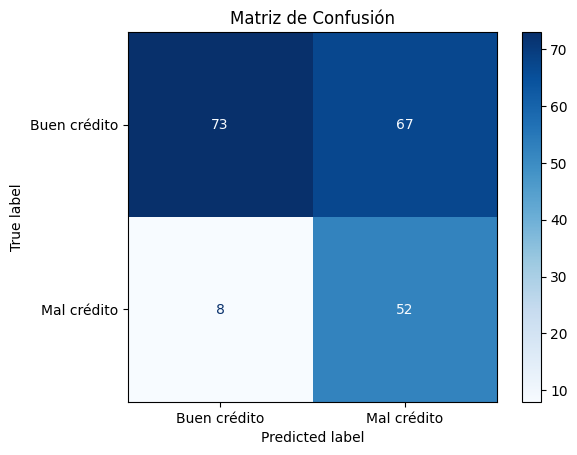

In [10]:
# Creamos matriz de confusión, para visualizar qué tanto se equivoca nuestro modelo
cm = confusion_matrix(y_test, predicciones, labels = [0,1])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=['Buen crédito','Mal crédito'] # Muestra tus etiquetas originales (0:bad y 1:good)
)

disp.plot(cmap=plt.cm.Blues)
plt.title(f"Matriz de Confusión")

### Obtenemos los pesos del modelo. 
Los coeficientes estimados por la regresión logística permiten analizar el peso o el poder de predicción qué posee cada variable, y cómo cada una influye en la probabilidad final asignada a cada observación con respecto a pertenecer a la clase que nos interesa, en este caso, si la observación representa un riesgo crediticio.
Un coeficiente positivo indica que dicha variable aumenta la probabilidad estimada de que el crédito sea riesgoso, mientras que un coeficiente negativo reduce dicha probabilidad.

Tener en cuenta que, debido a la utilización de One-Hot-Encoder, en donde utilizamos valores de referencia para cada variable, dichos coeficientes deben interpretarse respecto de la categoria de referencia definida durante el preprocesamiento.
Ejemplo de interpretación:

- cat__checking_status_<0 (coeficiente = 1.80).
La categoría de referencia para checking_status es no checking. Por lo tanto, manteniendo constantes las demás variables, un cliente con checking_status = <0 presenta una mayor probabilidad de pertenecer a la categoría bad en comparación con un cliente cuya categoría es no checking.

- cat__savings_status_>=1000 (coeficiente = -1.61).
La categoría de referencia para savings_status es <100. En consecuencia, manteniendo constantes las demás variables, un cliente con savings_status ≥1000 presenta una menor probabilidad de pertenecer a la categoría bad en comparación con un cliente con savings_status <100.

In [11]:
nombres_variables = pipeline.named_steps['modelo'].feature_names_in_
coeficientes = pipeline.named_steps['modelo'].coef_[0]

df_coeficientes_modelo = pd.DataFrame({
    'Variable' : nombres_variables,
    'Coeficientes' : coeficientes
}).sort_values(by='Coeficientes', key=abs, ascending = False)

print(df_coeficientes_modelo)

                                             Variable  Coeficientes
1                             cat__checking_status_<0      1.804106
18                         cat__savings_status_>=1000     -1.617599
47                                bin__foreign_worker      1.541390
9                              cat__purpose_education      1.531263
2                          cat__checking_status_>=200      1.410495
0                       cat__checking_status_0<=X<200      1.403050
13                               cat__purpose_repairs      1.308222
12                                 cat__purpose_other     -1.107145
25                  cat__personal_status_male div/sep      1.066798
32                      cat__other_payment_plans_bank      1.028426
15                              cat__purpose_used car     -0.962867
30          cat__property_magnitude_no known property      0.902207
37                   cat__job_unemp/unskilled non res     -0.870470
19               cat__savings_status_no known sa

### Observar las probabilidades asignadas a cada observación (Probabilidad de que la observación pertenezca a la clase "bad").

In [12]:
Probabilidades = ObtenerProbabilidades(pipeline, X_test, y_test)
Probabilidades.calcular_probabilidades()

,Clase real,Probabilidad buen crédito [0],Probabilidad mal crédito [1],Clase predicha,Score
30,0,0.494551,0.505449,1,0.021796
128,0,0.729597,0.270403,0,-0.992581
289,1,0.120046,0.879954,1,1.991993
216,0,0.133653,0.866347,1,1.869041
966,1,0.468216,0.531784,1,0.127309
...,...,...,...,...,...
522,1,0.013093,0.986907,1,4.322471
977,0,0.435718,0.564282,1,0.258559
52,0,0.778741,0.221259,0,-1.258345
542,1,0.166592,0.833408,1,1.609978


### Chequeo de multicolinealidad aproximada

1. Si bien el uso de One-Hot Encoding con categorías de referencia elimina la multicolinealidad perfecta entre las variables categóricas, aún podría existir multicolinealidad aproximada, es decir, relaciones lineales fuertes entre variables predictoras. Esto podría incrementar la varianza de los coeficientes, haciéndolos más inestables y dificultando su interpretación, debido a dicha inestabilidad.  

Para evaluar esta situación se calcula el Variance Inflation Factor (VIF) de cada variable predictora. El VIF cuantifica en qué medida una variable puede explicarse mediante una combinación lineal de las restantes variables del modelo. Valores elevados de VIF indican una mayor presencia de multicolinealidad y, en consecuencia, una mayor incertidumbre en la estimación de los coeficientes asociados a dichas variables.

In [13]:
X_train_trans = pipeline.named_steps['preprocesador'].transform(X_train)

vif = pd.DataFrame({
    "Variable": X_train_trans.columns,
    "VIF": [
        variance_inflation_factor(X_train_trans.values, i)
        for i in range(X_train_trans.shape[1])
    ]
})

vif = vif.sort_values("VIF", ascending=False)

print(vif)

                                             Variable       VIF
47                                bin__foreign_worker  9.631866
30          cat__property_magnitude_no known property  3.770299
34                              cat__housing_for free  3.439972
40                                 num__credit_amount  2.649538
4   cat__credit_history_critical/other existing cr...  2.440650
46                                 bin__own_telephone  2.252723
22                                cat__employment_>=7  2.206567
31                cat__property_magnitude_real estate  2.168415
39                                      num__duration  2.132837
24            cat__personal_status_female div/dep/mar  2.004184
11                               cat__purpose_new car  1.969051
1                             cat__checking_status_<0  1.945832
10                   cat__purpose_furniture/equipment  1.914604
0                       cat__checking_status_0<=X<200  1.906556
29             cat__property_magnitude_l

Podemos ver que no hay una gran correlación entre nuestras variables. Aquella que presenta un valor más elevado es una sola, "bin__foreign_worker". Vamos a evaluar con qué variables está relacionada:

In [14]:
corr = X_train_trans.corr(numeric_only=True)
corr["bin__foreign_worker"].sort_values(
    key=abs,
    ascending=False
).head(15)

bin__foreign_worker                       1.000000
cat__purpose_new car                     -0.158407
num__duration                             0.154033
bin__own_telephone                        0.113329
cat__other_parties_guarantor             -0.109975
cat__property_magnitude_real estate      -0.104888
num__installment_commitment               0.093247
cat__checking_status_0<=X<200             0.092069
cat__checking_status_<0                  -0.080091
num__credit_amount                        0.071961
num__num_dependents                      -0.071374
cat__housing_for free                     0.069682
cat__job_unemp/unskilled non res         -0.063842
cat__job_high qualif/self emp/mgmt        0.063805
cat__credit_history_delayed previously    0.063142
Name: bin__foreign_worker, dtype: float64

2. Evaluaremos el número de condicionamiento de nuestra matriz. El mismo nos ayudará a saber si nuestra matriz podría generar problemas de estabilidad numérica, ya que mientras mayor es el número de condicionamiento, más inestabilidad podrá generar. 

In [15]:
condition_number = np.linalg.cond(X_train_trans)

print(f"Número de condición: {condition_number:.2f}")

Número de condición: 19.67


### Decisión sobre regularización 
No se han detectado problemas sumamente graves respecto de la multicolinealidad o del número de condicionamiento de la matriz, lo que indica que obtendremos coeficientes relativamente estables. 
Sin embargo, debido a que nuestro dataset es pequeño, y hay categorias representadas por muy pocos datos, probaremos utilizar la regularización l2, ya que la misma podría mejorar la capacidad de generalización del modelo al reducir el sobreajuste. 
Aplicamos regularización l2 y luego compararemos los resultados obtenidos por ambos modelos. 

              precision    recall  f1-score   support

           0       0.90      0.52      0.66       140
           1       0.44      0.87      0.58        60

    accuracy                           0.62       200
   macro avg       0.67      0.69      0.62       200
weighted avg       0.76      0.62      0.64       200



Text(0.5, 1.0, 'Matriz de Confusión')

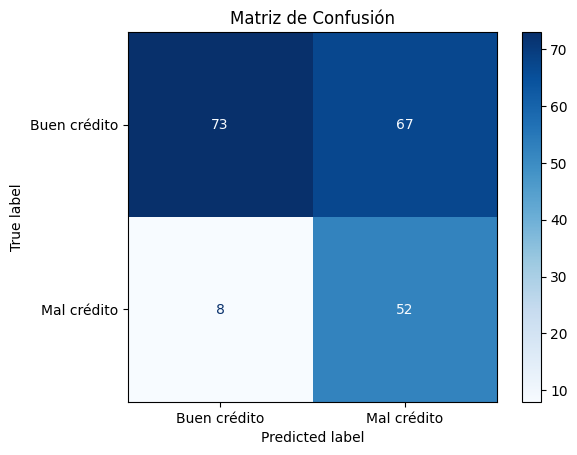

In [16]:
pipeline2 = Pipeline([
    ('preprocesador', DataPreProcessor(columnas_categoricas,referencias, columnas_numericas,columnas_binarias)),
    ('modelo', LogisticRegression(
    random_state=42,
    penalty = 'l2',
    class_weight=pesos))
])

pipeline2.fit(X_train, y_train)

predicciones2 = pipeline2.predict(X_test)
print(classification_report(y_test,predicciones2))

# Creamos matriz de confusión, para visualizar qué tanto se equivoca nuestro modelo
cm = confusion_matrix(y_test, predicciones2, labels = [0,1])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=['Buen crédito','Mal crédito'] # Muestra tus etiquetas originales (0:bad y 1:good)
)

disp.plot(cmap=plt.cm.Blues)
plt.title(f"Matriz de Confusión")



### Veamos cómo cambiaron nuestros coeficientes

In [17]:
nombres_variables2 = pipeline2.named_steps['modelo'].feature_names_in_
coeficientes2 = pipeline2.named_steps['modelo'].coef_[0]

df_coeficientes_modelo2 = pd.DataFrame({
    'Variable' : nombres_variables2,
    'Coeficientes' : coeficientes2
}).sort_values(by='Coeficientes', key=abs, ascending = False)

print(df_coeficientes_modelo2)

                                             Variable  Coeficientes
1                             cat__checking_status_<0      1.685903
18                         cat__savings_status_>=1000     -1.325637
9                              cat__purpose_education      1.312253
0                       cat__checking_status_0<=X<200      1.301337
47                                bin__foreign_worker      1.263079
2                          cat__checking_status_>=200      1.211371
13                               cat__purpose_repairs      0.970448
32                      cat__other_payment_plans_bank      0.965602
25                  cat__personal_status_male div/sep      0.944335
15                              cat__purpose_used car     -0.916531
4   cat__credit_history_critical/other existing cr...     -0.847118
19               cat__savings_status_no known savings     -0.824102
30          cat__property_magnitude_no known property      0.751455
6             cat__credit_history_no credits/all

In [18]:
comparacion = pd.DataFrame({
    "Variable": nombres_variables,
    "Sin regularización": coeficientes,
    "Con L2": coeficientes2
})

comparacion["Diferencia absoluta"] = (
    abs(comparacion["Con L2"] - comparacion["Sin regularización"])
)

comparacion = comparacion.sort_values(
    by="Diferencia absoluta",
    ascending=False
)

print(comparacion)

                                             Variable  Sin regularización  \
12                                 cat__purpose_other           -1.107145   
13                               cat__purpose_repairs            1.308222   
37                   cat__job_unemp/unskilled non res           -0.870470   
18                         cat__savings_status_>=1000           -1.617599   
47                                bin__foreign_worker            1.541390   
9                              cat__purpose_education            1.531263   
2                          cat__checking_status_>=200            1.410495   
14                            cat__purpose_retraining           -0.487758   
34                              cat__housing_for free           -0.504106   
30          cat__property_magnitude_no known property            0.902207   
25                  cat__personal_status_male div/sep            1.066798   
1                             cat__checking_status_<0            1.804106   

### COMPARACIÓN MODELO REGULARIZADO VS NO REGULARIZADO - MÉTRICAS DE EVALUACIÓN
Como se estableció en los objetivos del modelo, clasificar un mal crédito como bueno tiene un costo mucho mayor que clasificar un buen crédito como malo. Por este motivo, el modelo debe priorizar la detección de los clientes riesgosos, incluso si eso implica clasificar como riesgosos a buenos clientes.
Debido a esto, la métrica de mayor interés es el recall (o sensibilidad) de la clase positiva (correspondiente al mal crédito). Dicha métrica responde a la pregunta: de todos los crétidos que eran malos, cuantos fueron correctamente identificados como malos por el modelo? Cuántos de ellos nuestro modelo logró detectar?

Como pudimos ver, ambos modelos nos arrojaron un mismo valor de recall (0.87 para la clase positiva), por lo tanto no podemos obtener conclusiones aún. Debemos continuar evaluando.

In [19]:
modelos = {
    "Regresión logística sin regularización": pipeline,
    "Regresión logística con L2": pipeline2
}

### Evaluamos Presicion-Recall Curve. 
Debido a que estamos trabajando con créditos cuyas clases se encuentra desbalanceadas (naturalmente), utilizamos esta curva. Evalúa el trade-off entre Presicion y Recall. Mientras que la precision nos dice, de todos los que predijimos que eran malos créditos, cuántos fueron realmente malos, el recall nos dice: de todos los créditos que eran realmente malos, cuántos logramos detectar?

Es decir, nos muestra la capacidad del modelo entre capturar y detección correcta. Queremos que el modelo no esté capturando "demás", ya que también es necesario para la entidad financiera dar créditos y detectar los buenos clientes, como así es necesario detectar los que son malos créditos. 

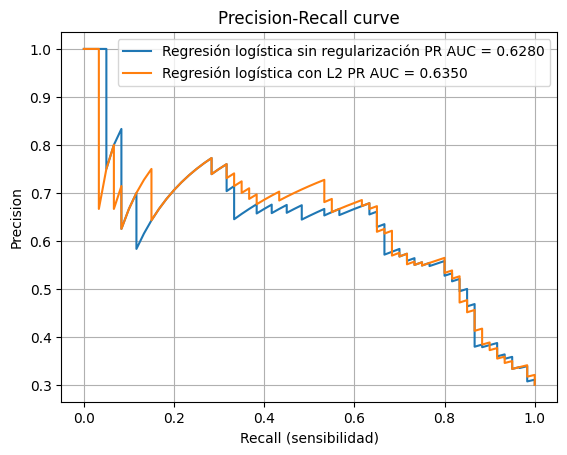

,Modelo,PR AUC
0,Regresión logística con L2,0.634982
1,Regresión logística sin regularización,0.627981


In [20]:
Curva_PR = CurvaPRComparaciones(modelos, X_test, y_test)
Curva_PR.crear_curva()

### Evaluación mediante la curva ROC

La curva ROC permite evaluar la capacidad del modelo para discriminar entre buenos y malos créditos a través de distintos umbrales de clasificación. Para ello, compara la tasa de verdaderos positivos, que en nuestro caso representa la proporción de malos créditos correctamente identificados, con la tasa de falsos positivos, es decir, la proporción de buenos créditos clasificados incorrectamente como malos.

Esta evaluación resulta útil porque permite analizar el equilibrio entre detectar una mayor cantidad de créditos riesgosos y evitar clasificar como riesgosos a clientes que realmente presentan un buen comportamiento crediticio. Además, el área bajo la curva, denominada ROC-AUC, resume la capacidad global del modelo para diferenciar ambas clases.


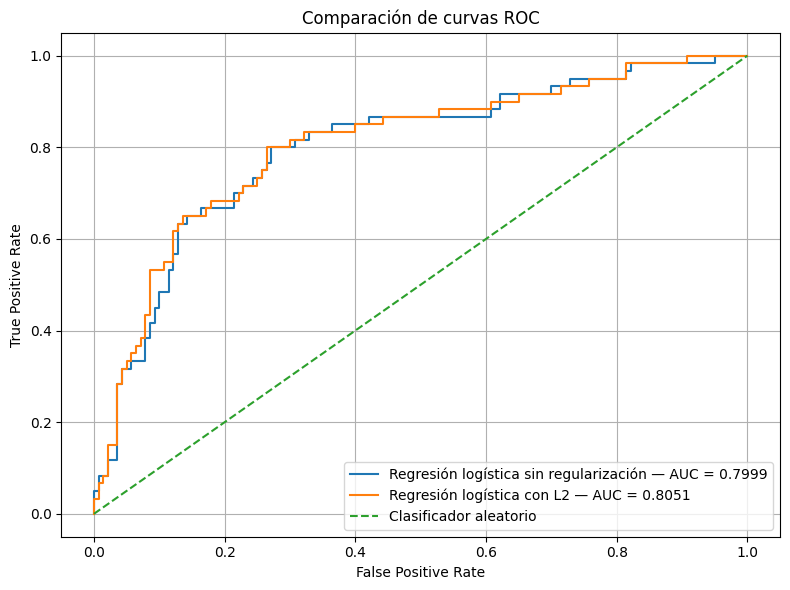

,Modelo,ROC AUC
1,Regresión logística con L2,0.805119
0,Regresión logística sin regularización,0.799881


In [21]:
CurvaROC_modelos = CurvaRocComparaciones(modelos, X_test, y_test)
CurvaROC_modelos.crear_curva()

### Validación cruzada

Por último, evaluamos ambos modelos mediante validación cruzada. El dataset utilizado es relativamente pequeño y algunas categorías cuentan con pocas observaciones, por este motivo, los resultados obtenidos a partir de una única división entre entrenamiento y prueba podrían depender considerablemente de las observaciones asignadas a cada conjunto.

La validación cruzada permite evaluar el modelo sobre distintas particiones de los datos y obtener una estimación más robusta de su rendimiento. De esta manera, podemos analizar si las métricas observadas se mantienen relativamente estables o si dependen en gran medida de una partición particular del dataset.

En este caso se utiliza validación cruzada estratificada, con el objetivo de conservar aproximadamente la proporción de buenos y malos créditos en cada partición. Para cada métrica se analiza tanto su valor medio como su desviación estándar.

Una desviación estándar baja indica que el desempeño del modelo es relativamente estable entre los distintos folds. Esto aporta evidencia de una mejor capacidad de generalización dentro de la muestra disponible. Sin embargo, no garantiza que el modelo mantenga exactamente el mismo rendimiento sobre cualquier conjunto de datos nuevo.


In [22]:
Validaciones = ValidacionCruzadaComparaciones(modelos, X_train, y_train)
Validaciones.evaluar()

,Modelo,recall_media,recall_std,precision_media,precision_std,f1_media,f1_std,roc_auc_media,roc_auc_std,average_precision_media,average_precision_std
0,Regresión logística sin regularización,0.804167,0.070465,0.438598,0.029781,0.567214,0.040494,0.756771,0.056710,0.571923,0.069692
1,Regresión logística con L2,0.825000,0.055277,0.438303,0.024226,0.572124,0.031648,0.764807,0.054235,0.583223,0.070748


## CONCLUSIONES FINALES 

La validación cruzada mostró que el modelo con regularización L2 obtuvo un desempeño ligeramente superior al modelo sin regularización. En particular, su recall medio aumentó de 0.804 a 0.825, lo que indica que logró detectar una mayor proporción de malos créditos. Esta mejora se produjo manteniendo prácticamente la misma precision, por lo que no implicó un aumento relevante en la proporción de buenos créditos clasificados incorrectamente como malos.

Asimismo, el modelo regularizado presentó una leve mejora  en F1, ROC-AUC y Average Precision, junto con una menor variabilidad en la mayoría de las métricas entre los distintos folds. Estos resultados aportan evidencia de un comportamiento ligeramente más estable y de una mejor capacidad predictiva fuera de las muestras utilizadas en cada entrenamiento.

En consecuencia, se selecciona al modelo con regularización L2 como modelo final. Esta decisión se fundamenta principalmente en su mayor recall, dado que en este problema resulta especialmente costoso clasificar como bueno a un crédito que realmente es malo.

No obstante, las diferencias entre ambos modelos son pequeñas, por lo que no puede afirmarse que el modelo regularizado sea sustancialmente superior. Ambos presentan un desempeño similar, aunque el modelo L2 ofrece una ventaja marginal en la detección de malos créditos y en la estabilidad de sus resultados.
